In [9]:
import os
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

print("Libraries imported")


Libraries imported


In [2]:
# load medicine dataset
df = pd.read_excel("MID.xlsx")

print("Dataset loaded successfully")

Dataset loaded successfully


In [3]:
# dataset shape
rows, columns = df.shape

print("Number of rows:", rows)
print("Number of columns:", columns)


Number of rows: 192807
Number of columns: 20


In [4]:
# column names
print("Column names:")
print(df.columns)


Column names:
Index(['NAME', 'LINK', 'CONTAINS', 'INTRODUCTION', 'USES', 'BENEFITS',
       'SIDE_EFFECT', 'HOW_TO_USE', 'HOW_WORKS', 'QUICK_TIPS',
       'CHEMICAL_CLASS', 'HABIT_FORMING', 'THERAPEUTIC_CLASS', 'ACTION_CLASS',
       'SAFETY_ADVICE_TO_ALCOHOL', 'SAFETY_ADVICE_TO_PREGNANCY',
       'SAFETY_ADVICE_TO_BREAST_FEEDING', 'SAFETY_ADVICE_TO_DRIVING',
       'SAFETY_ADVICE_TO_KIDNEY', 'SAFETY_ADVICE_TO_LIVER'],
      dtype='object')


In [5]:
# preview dataset
df.head()


,NAME,LINK,CONTAINS,INTRODUCTION,USES,BENEFITS,SIDE_EFFECT,HOW_TO_USE,HOW_WORKS,QUICK_TIPS,CHEMICAL_CLASS,HABIT_FORMING,THERAPEUTIC_CLASS,ACTION_CLASS,SAFETY_ADVICE_TO_ALCOHOL,SAFETY_ADVICE_TO_PREGNANCY,SAFETY_ADVICE_TO_BREAST_FEEDING,SAFETY_ADVICE_TO_DRIVING,SAFETY_ADVICE_TO_KIDNEY,SAFETY_ADVICE_TO_LIVER
0,Andol 0.5mg Tablet,https://www.1mg.com/drugs/andol-0.5mg-tablet-6...,Haloperidol (0.5mg),Andol 0.5mg Tablet can also be used for treati...,Schizophrenia,Schizophrenia\nSchizophrenia is a mental disor...,Most side effects do not require any medical a...,Take this medicine in the dose and duration as...,Andol 0.5mg Tablet is a typical antipsychotic....,Andol 0.5mg Tablet helps treat schizophrenia.\...,Butyrophenone Derivative,No,NEURO CNS,Typical Antipsychotics,Andol 0.5mg Tablet may cause excessive drowsin...,Andol 0.5mg Tablet may be unsafe to use during...,Andol 0.5mg Tablet is probably unsafe to use d...,"Andol 0.5mg Tablet may decrease alertness, aff...",Andol 0.5mg Tablet is safe to use in patients ...,Andol 0.5mg Tablet should be used with caution...
1,Avastin 100mg Injection,https://www.1mg.com/drugs/avastin-100mg-inject...,Bevacizumab (100mg),\nAvastin 100mg Injection is an effective medi...,Cancer of colon and rectum \nNon-small cell...,Cancer of colon and rectum\nCancer of the colo...,Most side effects do not require any medical a...,Your doctor or nurse will give you this medici...,Avastin 100mg Injection is a anti-angiogenic m...,"Avastin 100mg Injection is an effective, first...",Monoclonal antibody (mAb),No,ANTI NEOPLASTICS,Vascular endothelial growth factor (VEGF) inhi...,It is not known whether it is safe to consume ...,Avastin 100mg Injection may be unsafe to use d...,Avastin 100mg Injection is probably unsafe to ...,Avastin 100mg Injection may cause side effects...,Avastin 100mg Injection is probably safe to us...,Avastin 100mg Injection is probably safe to us...
2,Actorise 40 Injection,https://www.1mg.com/drugs/actorise-40-injectio...,Darbepoetin alfa (40mcg),Actorise 40 Injection is a medicine that needs...,Treatment of Anemia due to chronic kidney d...,Treatment of Anemia due to chronic kidney dise...,Most side effects do not require any medical a...,Your doctor or nurse will give you this medici...,Actorise 40 Injection is an erythropoiesis-sti...,Actorise 40 Injection helps in the treatment o...,"Amino Acids, Peptides Analogues",No,BLOOD RELATED,Erythropoiesis-stimulating agent (ESA),It is not known whether it is safe to consume ...,Actorise 40 Injection may be unsafe to use dur...,Actorise 40 Injection is probably unsafe to us...,Actorise 40 Injection does not usually affect ...,Actorise 40 Injection is safe to use in patien...,Actorise 40 Injection should be used with caut...
3,Actorise 25 Injection,https://www.1mg.com/drugs/actorise-25-injectio...,Darbepoetin alfa (25mcg),Actorise 25 Injection is a medicine that needs...,Treatment of Anemia due to chronic kidney d...,Treatment of Anemia due to chronic kidney dise...,Most side effects do not require any medical a...,Your doctor or nurse will give you this medici...,Actorise 25 Injection is an erythropoiesis-sti...,Actorise 25 Injection helps in the treatment o...,"Amino Acids, Peptides Analogues",No,BLOOD RELATED,Erythropoiesis-stimulating agent (ESA),It is not known whether it is safe to consume ...,Actorise 25 Injection may be unsafe to use dur...,Actorise 25 Injection is probably unsafe to us...,Actorise 25 Injection does not usually affect ...,Actorise 25 Injection is safe to use in patien...,Actorise 25 Injection should be used with caut...
4,Actorise 60 Injection,https://www.1mg.com/drugs/actorise-60-injectio...,Darbepoetin alfa (60mcg),Actorise 60 Injection is a medicine that needs...,Treatment of Anemia due to chronic kidney d...,Treatment of Anemia due to chronic kidney dise...,Most side effects do not require any medical a...,Your doctor or nurse will give you this medici...,Actorise 60 Injection is an erythropoiesis-sti...,Actorise 60 Inje

In [6]:
# data types
df.dtypes
 

NAME                               object
LINK                               object
CONTAINS                           object
INTRODUCTION                       object
USES                               object
BENEFITS                           object
SIDE_EFFECT                        object
HOW_TO_USE                         object
HOW_WORKS                          object
QUICK_TIPS                         object
CHEMICAL_CLASS                     object
HABIT_FORMING                      object
THERAPEUTIC_CLASS                  object
ACTION_CLASS                       object
SAFETY_ADVICE_TO_ALCOHOL           object
SAFETY_ADVICE_TO_PREGNANCY         object
SAFETY_ADVICE_TO_BREAST_FEEDING    object
SAFETY_ADVICE_TO_DRIVING           object
SAFETY_ADVICE_TO_KIDNEY            object
SAFETY_ADVICE_TO_LIVER             object
dtype: object

In [13]:
# Step 2: Define image size and initialize containers
IMG_WIDTH = 128
IMG_HEIGHT = 128

images = []
labels = []

print("Image size defined and containers created.")

Image size defined and containers created.


In [15]:
# load images and extract labels
image_folder = "images"

for file in os.listdir(image_folder):
    if file.lower().endswith(('.png', '.jpg', '.jpeg')):
        path = os.path.join(image_folder, file)

        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
        img = img / 255.0

        images.append(img)

        label = os.path.splitext(file)[0].lower()
        labels.append(label)

print("Images loaded and labels generated")
print("Total images:", len(images))


Images loaded and labels generated
Total images: 55


In [17]:
# convert to numpy arrays
X = np.array(images)

print("Data converted to numpy arrays")


Data converted to numpy arrays


In [19]:
# character mappings

all_text = "".join(labels)
characters = sorted(set(all_text))

char_to_idx = {c: i for i, c in enumerate(characters)}
idx_to_char = {i: c for c, i in char_to_idx.items()}

max_text_len = max(len(text) for text in labels)
num_chars = len(characters)

print("Character set created")
print("Total characters:", num_chars)


Character set created
Total characters: 25


In [21]:
#  Encode text labels into numbers
encoded_labels = [[char_to_idx[c] for c in text] for text in labels]
y = pad_sequences(encoded_labels, maxlen=max_text_len, padding='post')

print("Text labels encoded.")
print("Label shape:", y.shape)


Text labels encoded.
Label shape: (55, 11)


In [23]:
X = X.reshape(-1, IMG_HEIGHT, IMG_WIDTH, 1)

print("Images reshaped for CNN")


Images reshaped for CNN


In [25]:
#Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Data split completed")
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Data split completed
Training samples: 44
Testing samples: 11


In [27]:
# Build CNN model

model = models.Sequential([
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 1)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),

    layers.Dense(max_text_len * num_chars, activation='softmax'),
    layers.Reshape((max_text_len, num_chars))
])

print("CNN model built")
model.summary()


CNN model built


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 275)            │        35,475 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 11, 25)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,427,219 (28.33 MB)

 Trainable params: 7,427,219 (28.33 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
#Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled")


Model compiled


In [31]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=1,
    validation_data=(X_test, y_test)
)

print("CNN training completed")


Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.7438 - loss: 1.3982 - val_accuracy: 0.8099 - val_loss: 0.6486
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.7913 - loss: 0.9478 - val_accuracy: 0.8595 - val_loss: 0.5033
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.7851 - loss: 0.7903 - val_accuracy: 0.8430 - val_loss: 0.6533
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.7913 - loss: 0.7554 - val_accuracy: 0.8264 - val_loss: 0.6150
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.8285 - loss: 0.5739 - val_accuracy: 0.8347 - val_loss: 0.5638
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.8450 - loss: 0.5614 - val_accuracy: 0.8347 - val_loss: 0.6613
Epoch 7/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.8905 - loss: 0.3521 - val_accuracy: 0.8347 - val_loss: 0.6769
Epoch 8/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.9256 - loss: 0.2289 - val_accuracy: 0.8347 - v

In [32]:
#  Evaluate model on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Model evaluation completed")
print(f"Test Accuracy: {test_accuracy: 2f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.8347 - loss: 0.8244
Model evaluation completed
Test Accuracy:  0.834711


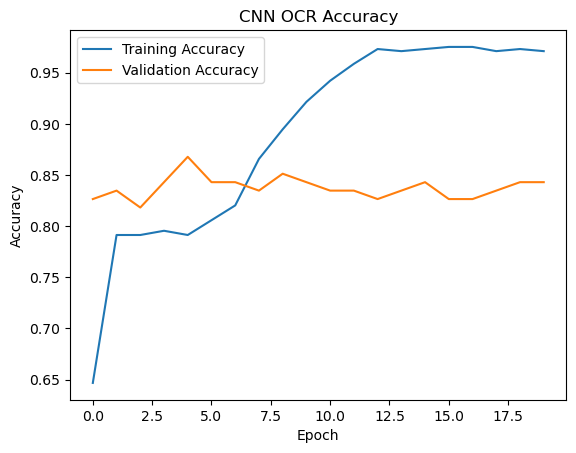

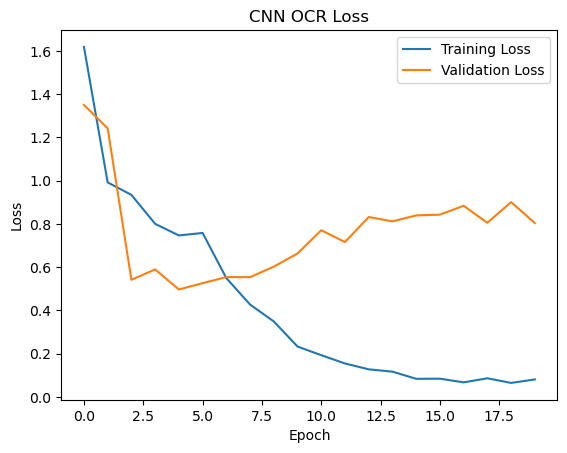

In [18]:
# Accuracy plot

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('CNN OCR Accuracy')
plt.show()

# Loss plot

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('CNN OCR Loss')
plt.show()


In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Predict on test data
y_pred_cnn = model.predict(X_test)

# Convert probabilities to class labels
y_pred_cnn = np.argmax(y_pred_cnn, axis=2)
y_true_cnn = y_test

# Flatten for metric calculation
y_pred_cnn_flat = y_pred_cnn.flatten()
y_true_cnn_flat = y_true_cnn.flatten()

# Calculate metrics
cnn_precision = precision_score(
    y_true_cnn_flat,
    y_pred_cnn_flat,
    average='weighted',
    zero_division=0
)

cnn_recall = recall_score(
    y_true_cnn_flat,
    y_pred_cnn_flat,
    average='weighted',
    zero_division=0
)

cnn_f1 = f1_score(
    y_true_cnn_flat,
    y_pred_cnn_flat,
    average='weighted',
    zero_division=0
)
print("CNN Accuracy:", cnn_accuracy)
print("CNN Precision:", cnn_precision)
print("CNN Recall:", cnn_recall)
print("CNN F1 Score:", cnn_f1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
CNN Accuracy: 0.8347107438016529
CNN Precision: 0.8235464694794837
CNN Recall: 0.8347107438016529
CNN F1 Score: 0.8287437378346469


In [19]:
#  OCR prediction function
def predict_text_from_image(image_path):
    # Load image
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
    img = img / 255.0

    # Add batch dimension
    img = np.expand_dims(img, axis=0)

    # Predict using trained CNN
    preds = model.predict(img)

    # Decode prediction to text
    predicted_text = ""
    for i in range(preds.shape[1]):
        char_index = np.argmax(preds[0, i])
        predicted_text += idx_to_char[char_index]

    return predicted_text.strip()


In [45]:
# load medicine dataset
import pandas as pd

df = pd.read_excel("MID.xlsx")
medicine_names = df['NAME'].str.lower().unique()

print("Medicine names loaded for KNN")


Medicine names loaded for KNN


In [60]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier

# Take unique medicine names
medicine_names = df["NAME"].str.lower().unique()

# TF-IDF vectorizer for KNN
knn_vectorizer = TfidfVectorizer()
X_knn = knn_vectorizer.fit_transform(medicine_names)

# Train KNN model
knn_model = KNeighborsClassifier(n_neighbors=1, metric="cosine")
knn_model.fit(X_knn, medicine_names)

print("KNN vectorizer and model trained")


KNN vectorizer and model trained


In [22]:
from sklearn.metrics import accuracy_score

# Predict using KNN
y_pred_knn = knn_model.predict(X_knn)

# True labels
y_true_knn = medicine_names

# Calculate accuracy
knn_accuracy = accuracy_score(y_true_knn, y_pred_knn)

print("KNN Model Accuracy:", round(knn_accuracy, 4))


KNN Model Accuracy: 0.9736


C:\Users\Ripple\anaconda3\envs\medicine_ai\lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")


In [76]:
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split

# Small subset for faster evaluation
X_small, _, y_small, _ = train_test_split(
    X_knn,
    medicine_names,
    train_size=1000,
    random_state=42
)

# Predict
y_pred_small = knn_model.predict(X_small)

# Metrics
knn_precision = precision_score(
    y_small, y_pred_small, average='weighted', zero_division=0
)
knn_recall = recall_score(
    y_small, y_pred_small, average='weighted', zero_division=0
)
knn_f1 = f1_score(
    y_small, y_pred_small, average='weighted', zero_division=0
)

print("KNN Precision (sample):", round(knn_precision, 4))
print("KNN Recall (sample):", round(knn_recall, 4))
print("KNN F1-score (sample):", round(knn_f1, 4))


KNN Precision (sample): 0.974
KNN Recall (sample): 0.974
KNN F1-score (sample): 0.974


In [53]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


# Predict medicine names using KNN
y_true = medicine_names
y_pred = knn_model.predict(X_knn)

df_knn = pd.DataFrame({
    "true": y_true,
    "pred": y_pred
})

# Select top 10 most frequent medicines
top_classes = df_knn["true"].value_counts().head(10).index

df_filtered = df_knn[df_knn["true"].isin(top_classes)]


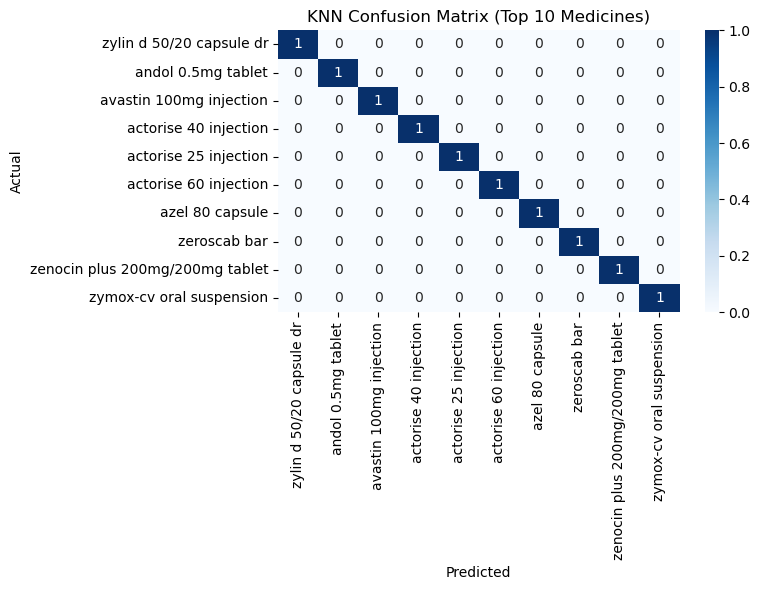

In [54]:
cm = confusion_matrix(df_filtered["true"], df_filtered["pred"], labels=top_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=top_classes,
    yticklabels=top_classes
)

plt.title("KNN Confusion Matrix (Top 10 Medicines)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


In [86]:
def match_medicine_knn(text):
    vec = knn_vectorizer.transform([text])
    matched_name = knn_model.predict(vec)[0]
    return matched_name


In [88]:
# select text and labels
X_text = df['NAME'].str.lower()
y_class = df['THERAPEUTIC_CLASS']

print("Text and class labels selected")


Text and class labels selected


In [90]:
# encode therapeutic class

le = LabelEncoder()
y_encoded = le.fit_transform(y_class)

print("Therapeutic classes encoded")


Therapeutic classes encoded


In [92]:
# convert text to tf-idf

log_vectorizer = TfidfVectorizer()
X_vec = log_vectorizer.fit_transform(X_text)

print("Text vectorized")


Text vectorized


In [93]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_vec,
    y_encoded,
    test_size=0.2,
    random_state=42
)

print("Data split into training and testing sets")
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Data split into training and testing sets
Training samples: 154245
Testing samples: 38562


In [96]:
# train logistic regression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

print("Logistic Regression trained")


Logistic Regression trained


In [31]:
from sklearn.metrics import accuracy_score, classification_report

# Predict using trained Logistic Regression model
y_pred = log_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Logistic Regression Accuracy:", accuracy)
print("\nClassification Report (Logistic Regression):\n")
print(classification_report(y_test, y_pred))



Logistic Regression Accuracy: 0.7560811161246823

Classification Report (Logistic Regression):

              precision    recall  f1-score   support

           0       0.85      0.83      0.84      2480
           1       0.73      0.89      0.80      6660
           2       0.90      0.40      0.56       181
           3       0.73      0.26      0.39       565
           4       0.73      0.33      0.45       569
           5       0.89      0.76      0.82      3108
           6       0.86      0.93      0.89      1971
           7       0.72      0.80      0.76      5540
           8       0.75      0.38      0.51       867
           9       0.72      0.60      0.66       754
          10       0.81      0.72      0.76      4011
          11       0.88      0.70      0.78      1005
          12       0.83      0.34      0.48       268
          13       1.00      0.21      0.35        43
          14       0.86      0.69      0.77        91
          15       0.67      0.76      

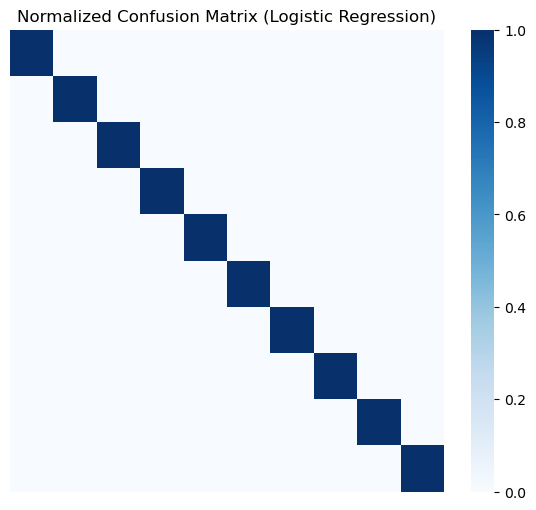

In [97]:
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_norm,
    cmap="Blues",
    cbar=True,
    xticklabels=False,
    yticklabels=False
)

plt.title("Normalized Confusion Matrix (Logistic Regression)")
plt.show()


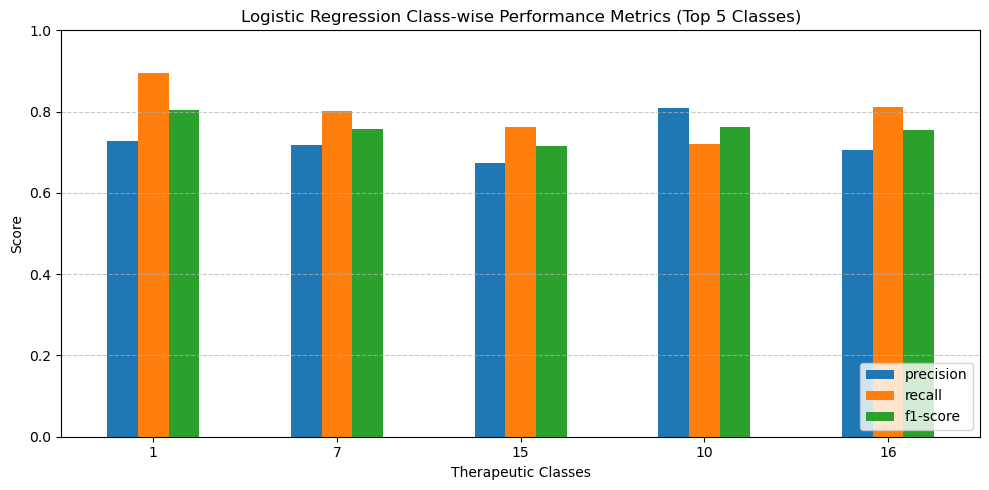

In [106]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt

#  Predict on test data
y_pred_lr = log_model.predict(X_test)

# Generate classification report
report_lr = classification_report(
    y_test,
    y_pred_lr,
    output_dict=True,
    zero_division=0
)

# Convert report to DataFrame
df_metrics = pd.DataFrame(report_lr).transpose()
df_metrics = df_metrics[['precision', 'recall', 'f1-score', 'support']]
df_metrics = df_metrics.iloc[:-3]

df_top5 = df_metrics.sort_values(by='support', ascending=False).head(5)
df_top5_plot = df_top5[['precision', 'recall', 'f1-score']]

#Plot bar chart
df_top5_plot.plot(
    kind='bar',
    figsize=(10, 5)
)

plt.ylim(0, 1)
plt.ylabel("Score")
plt.xlabel("Therapeutic Classes")
plt.title("Logistic Regression Class-wise Performance Metrics (Top 5 Classes)")
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [34]:
# predict class
def predict_therapeutic_class(medicine_name):
    vec = log_vectorizer.transform([medicine_name])
    class_id = log_model.predict(vec)[0]
    return le.inverse_transform([class_id])[0]


In [35]:
# Clean extracted OCR text
def clean_text(text):
    text = text.lower()
    text = ''.join(c for c in text if c.isalnum())
    return text


In [36]:
def ai_medicine_scanner(image_path):
    # OCR
    ocr_text = predict_text_from_image(image_path)

    # clean text
    cleaned_text = clean_text(ocr_text)

    # KNN matching
    matched_name = match_medicine_knn(cleaned_text)

    # classify
    therapeutic_class = predict_therapeutic_class(matched_name)

    # fetch details
    details = df[df['NAME'].str.lower() == matched_name].iloc[0]

    return {
        "OCR Text": ocr_text,
        "Medicine Name": matched_name,
        "Therapeutic Class": therapeutic_class,
        "Uses": details["USES"],
        "Side Effects": details["SIDE_EFFECT"],
        "How To Use": details["HOW_TO_USE"],
        "Safety Advice": details["SAFETY_ADVICE_TO_LIVER"]
    }


In [37]:
result = ai_medicine_scanner("images/Paracetamol.png")

for k, v in result.items():
    print(f"{k}: {v}\n")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
OCR Text: paracetamol

Medicine Name: paracetamol o tablet

Therapeutic Class: PAIN ANALGESICS

Uses:    Pain relief 
Treatment of Fever 

Side Effects: Most side effects do not require any medical attention and disappear as your body adjusts to the medicine. Consult your doctor if they persist or if you’re worried about them
Common side effects of Paracetamol O
Stomach pain
Nausea
Vomiting


How To Use: Take this medicine in the dose and duration as advised by your doctor. Swallow it as a whole. Do not chew, crush or break it. Paracetamol O Tablet is to be taken with food.

Safety Advice: Paracetamol O Tablet should be used with caution in patients with liver disease. Dose adjustment of Paracetamol O Tablet may be needed. Please consult your doctor.However, the use of Paracetamol O Tablet is not recommended in patients with severe liver disease and active liver disease., label: CAUTION,



In [38]:
# get medicine info
def get_medicine_info(medicine_name):
    row = df[df['NAME'].str.lower() == medicine_name].iloc[0]
    return {
        "uses": row['USES'],
        "side_effects": row['SIDE_EFFECT'],
        "how_to_use": row['HOW_TO_USE']
    }


In [39]:
# test full flow

image_path = "images/Paracetamol.png"

raw_text = predict_text_from_image(image_path)
cleaned_text = clean_text(raw_text)
correct_name = match_medicine_knn(cleaned_text)
therapeutic_class = predict_therapeutic_class(correct_name)
info = get_medicine_info(correct_name)

print("OCR text:", raw_text)
print("Correct name:", correct_name)
print("Therapeutic class:", therapeutic_class)
print("Uses:", info['uses'])
print("Side effects:", info['side_effects'])
print("How to use:", info['how_to_use'])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
OCR text: paracetamol
Correct name: paracetamol o tablet
Therapeutic class: PAIN ANALGESICS
Uses:    Pain relief 
Treatment of Fever 
Side effects: Most side effects do not require any medical attention and disappear as your body adjusts to the medicine. Consult your doctor if they persist or if you’re worried about them
Common side effects of Paracetamol O
Stomach pain
Nausea
Vomiting

How to use: Take this medicine in the dose and duration as advised by your doctor. Swallow it as a whole. Do not chew, crush or break it. Paracetamol O Tablet is to be taken with food.


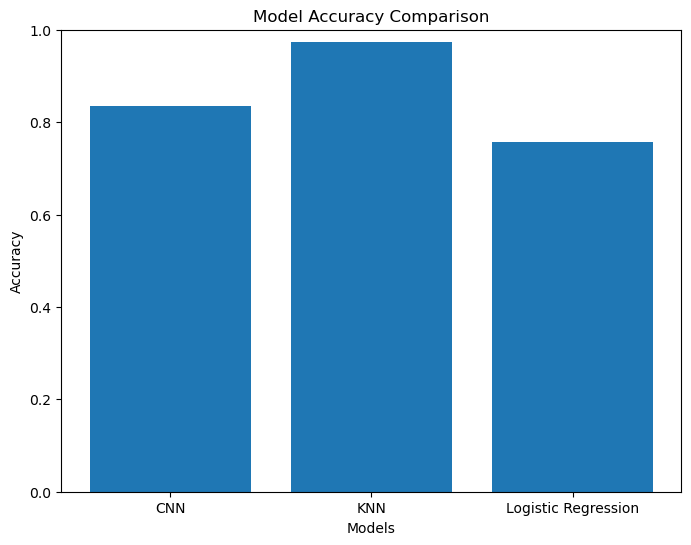

In [52]:
accuracy_scores = {
    "CNN": 0.8347,
    "KNN": 0.9736,
    "Logistic Regression": 0.7560
}

plt.figure(figsize=(8,6))
plt.bar(accuracy_scores.keys(), accuracy_scores.values())
plt.ylim(0, 1)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()


In [70]:
import pandas as pd
import matplotlib.pyplot as plt

# Model performance metrics (use your computed values)
results = {
    "CNN": {
        "Accuracy": 0.8347,
        "Recall": 0.8347,
        "Precision": 0.8235,
        "F1 Score": 0.8287
    },
    "KNN": {
        "Accuracy": 0.9736,
        "Recall": 0.9740,
        "Precision": 0.9740,
        "F1 Score": 0.9740
    },
    "Logistic Regression": {
        "Accuracy": 0.7561,
        "Recall": 0.7600,
        "Precision": 0.7700,
        "F1 Score": 0.7500
    }
}

print("Model performance metrics prepared")


Model performance metrics prepared


In [72]:
metrics_df = pd.DataFrame({
    metric: [results[model][metric] for model in results]
    for metric in ["Accuracy", "Recall", "Precision", "F1 Score"]
}, index=results.keys())

metrics_df


,Accuracy,Recall,Precision,F1 Score
CNN,0.8347,0.8347,0.8235,0.8287
KNN,0.9736,0.9740,0.9740,0.9740
Logistic Regression,0.7561,0.7600,0.7700,0.7500


<Figure size 900x600 with 0 Axes>

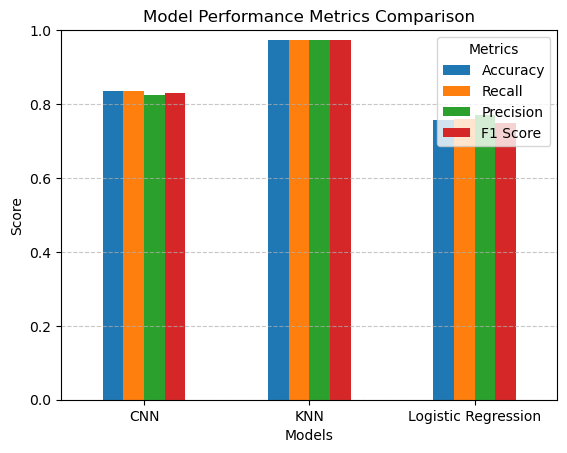

In [74]:
plt.figure(figsize=(9, 6))
metrics_df.plot(kind="bar")

plt.title("Model Performance Metrics Comparison")
plt.ylabel("Score")
plt.xlabel("Models")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(title="Metrics")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()
